In [ ]:
# Fitting a function with gradient descent
# A neural network is just a mathematical function. In the most standard kind of neural network, the function:

# Multiplies each input by a number of values. These values are known as parameters
# Adds them up for each group of values
# Replaces the negative numbers with zeros
# This represents one "layer". Then these three steps are repeated, using the outputs of the previous layer as the inputs to the next layer. Initially, the parameters in this function are selected randomly. Therefore a newly created neural network doesn't do anything useful at all -- it's just random!

# To get the function to "learn" to do something useful, we have to change the parameters to make them "better" in some way. We do this using gradient descent.

In [1]:
from ipywidgets import interact
from fastai.basics import *

In [2]:
plt.rc('figure', dpi=90)

In [3]:
def plot_function(f, title=None, min=-2.1, max=2.1, color='r', ylim=None):
    x = torch.linspace(min,max, 100)[:,None]
    if ylim: plt.ylim(ylim)
    plt.plot(x, f(x), color)
    if title is not None: plt.title(title)

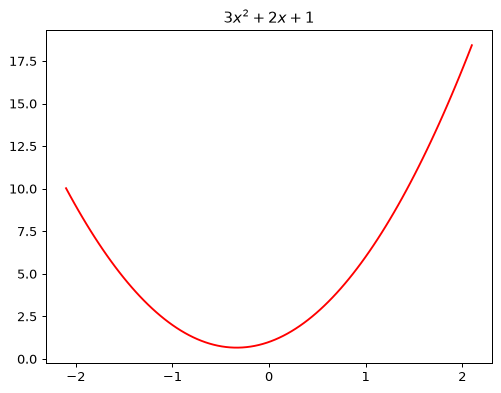

In [4]:
# To learn how gradient descent works, we're going to start by fitting a quadratic:
def f(x): return 3*x**2 + 2*x + 1

plot_function(f, "$3x^2 + 2x + 1$")

In [5]:
# This quadratic is of the form ax**2 + bx + c, with parameters  
# a = 3, b = 2, c = 1
# To make it easier to try out different quadratics for fitting a model to the data 
# we'll create, let's create a function that calculates the value of a point on any 
# quadratic:
def quad(a, b, c, x): return a*x**2 + b*x + c

In [6]:
# If we fix some particular values of a, b, and c, then we'll have made a quadratic. 
# To fix values passed to a function in python, we use the partial function, like so:
def mk_quad(a,b,c): return partial(quad, a,b,c)

In [ ]:
# A partial function allows you to fix a certain number of arguments of an existing 
# function and generate a new, specialized function with a simplified signature

# # A standard function with 2 arguments
# def multiply(x, y):
#     return x * y

# # Create a specialized function that always multiplies by 2
# double = partial(multiply, 2)

# # Call the new function with the remaining argument
# print(double(5))  # Output: 10

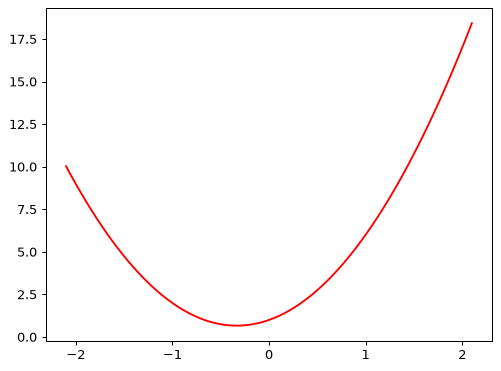

In [7]:
# So for instance, we can recreate our previous quadratic:
f2 = mk_quad(3,2,1)
plot_function(f2)

In [1]:
# Add noise to our quadratic function so that it is closer to actual data
def noise(x, scale): return np.random.normal(scale=scale, size=x.shape)

def add_noise(x, mult, add): return x * (1+noise(x,mult)) + noise(x,add)

In [ ]:
np.random.seed(42) # So that we get the same noise every time

x = torch.linspace(-2, 2, steps=20)[:,None]
y = add_noise(f(x), 0.15, 1.5)

In [ ]:
# These are tensors. A tensor is just like an array in numpy. A tensor can be a 
# single number (a scalar or rank-0 tensor), a list of numbers (a vector or rank-1 
# tensor), a table of numbers (a matrix or rank-2 tensor), a table of tables of 
# numbers (a rank-3 tensor), and so forth.
x[:5],y[:5]

In [ ]:
plt.scatter(x,y);